# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

C:\Users\viver\AppData\Local\Temp\ipykernel_1356\685848581.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [2]:
rent_by_month = df["count"].resample("MS").mean()

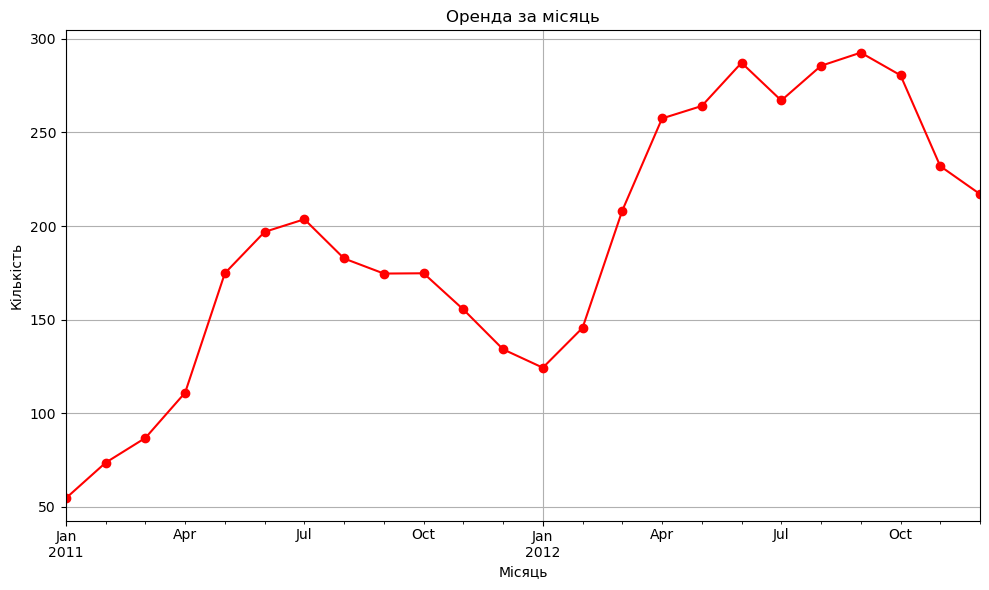

In [3]:
# Pandas

rent_by_month.plot(
    marker='o',
    color='red',
    figsize=(10, 6),
    title='Оренда за місяць',
    xlabel='Місяць',
    ylabel='Кількість',
    grid=True
)

plt.tight_layout()

plt.savefig("rent_by_month_Pandas.png", dpi=300, bbox_inches="tight")
plt.show()

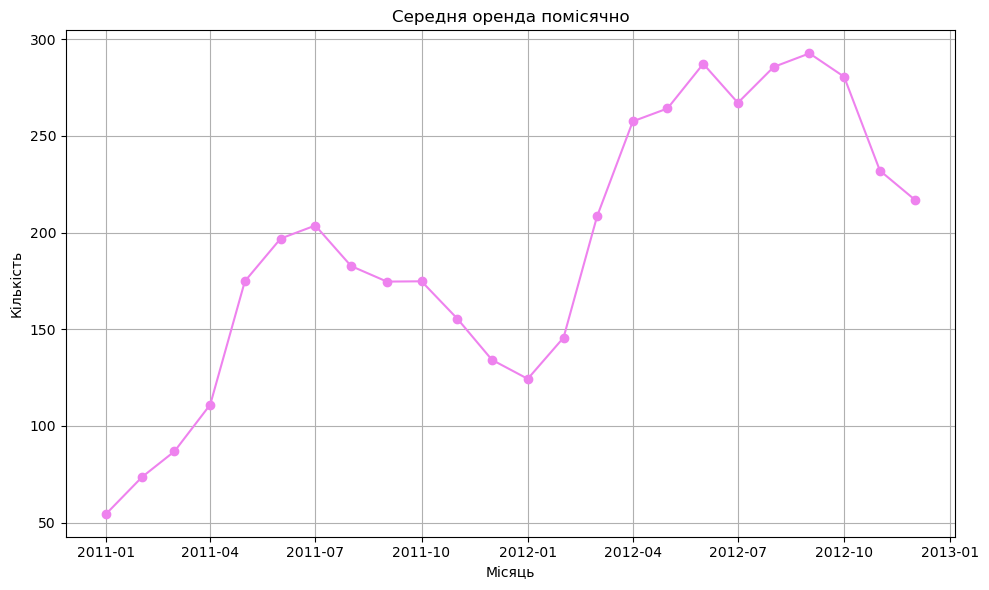

In [4]:
# Matplotlib

plt.figure(figsize=(10, 6))

plt.plot(
    rent_by_month.index,
    rent_by_month.values,
    marker='o',
    color='violet'
)

plt.title('Середня оренда помісячно')
plt.xlabel('Місяць')
plt.ylabel('Кількість')
plt.grid(True)

plt.tight_layout()
plt.savefig("rent_by_month_Matplotlib.png", dpi=300, bbox_inches="tight")
plt.show()

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [5]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

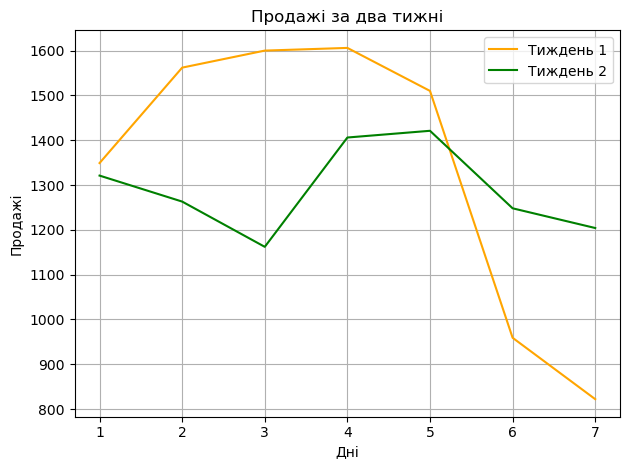

In [6]:
plt.figure()  

plt.subplot(1, 1, 1)  # (рядки, колонки, номер панелі)
plt.title("Продажі за два тижні")
plt.plot(days, sales_week1, color="orange", label="Тиждень 1")
plt.plot(days, sales_week2, color="green", label="Тиждень 2")
plt.xlabel("Дні")
plt.ylabel("Продажі")

plt.legend()   #  легенда
plt.grid(True)

plt.tight_layout()

plt.savefig("sales_by_week.png", dpi=300, bbox_inches="tight")
plt.show();

In [7]:
std_sales_week1 = np.std(sales_week1)
std_sales_week2 = np.std(sales_week2)

print("Std week 1:", std_sales_week1)
print("Std week 2:", std_sales_week2)

Std week 1: 299.99857142517004
Std week 2: 90.9060964256355


Судячи з графіку, в який тиждень проодажі були стабільніше?
візуально продажі 2 тижня є стабільнішими.

Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.
через стандартне відхилення - для 2 тижня воно втричі менше, аніж для 1тижня


## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [8]:
df.head(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,Saturday,5,52,2011,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,Saturday,5,52,2011,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,2,Saturday,5,52,2011,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1,3,Saturday,5,52,2011,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1,4,Saturday,5,52,2011,1


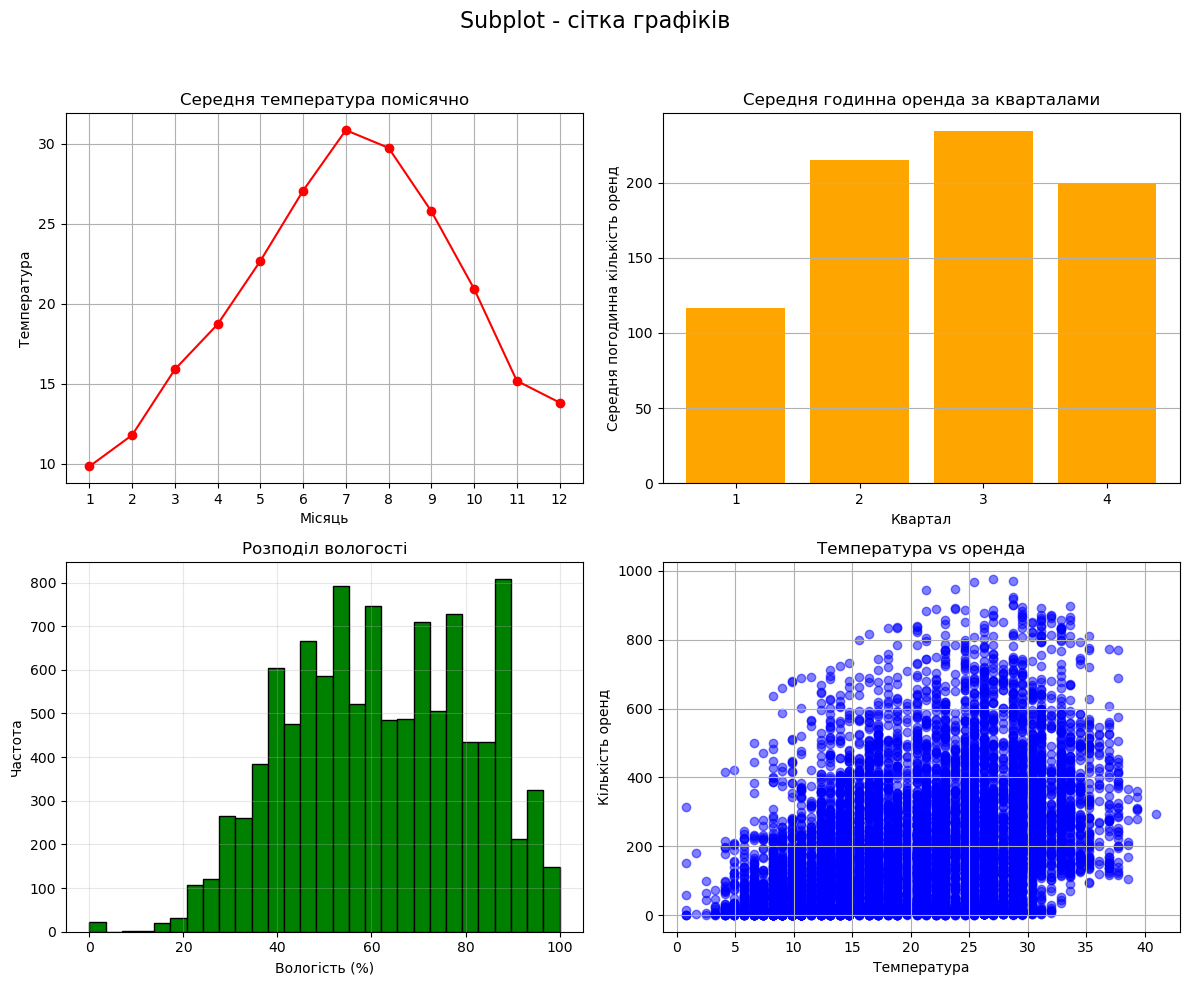

In [10]:
plt.figure(figsize=(12, 10)) 

# Графік 1 - Лінійний графік 
temp_by_month = df.groupby("month")["temp"].mean()

plt.subplot(2, 2, 1)
plt.plot(temp_by_month.index, temp_by_month.values, marker='o', color="red")
plt.title("Середня температура помісячно")
plt.xlabel("Місяць")
plt.ylabel("Температура")
plt.xticks(range(1, 13))
plt.grid(True)


# Графік 2 - Стовпчикова діаграма
rent_by_season = df.groupby("season")["count"].mean()

plt.subplot(2, 2, 2)
plt.bar(rent_by_season.index, rent_by_season.values, color="orange")
plt.xlabel("Квартал")
plt.ylabel("Середня погодинна кількість оренд")
plt.title("Середня годинна оренда за кварталами")
plt.xticks([1,2,3,4])
plt.grid(axis='y')


# Графік 3 - Гістограма
bins = np.linspace(df["humidity"].min(), df["humidity"].max(), 30)

plt.subplot(2, 2, 3)
plt.hist(df["humidity"], bins=bins, color="green",edgecolor="black")
plt.title("Розподіл вологості")
plt.xlabel("Вологість (%)")
plt.ylabel("Частота")
plt.grid(True, alpha=0.3)

# Графік 4 - Scatter
scatter_df = df[["temp", "count"]].copy()

plt.subplot(2, 2, 4)
plt.scatter(scatter_df["temp"], scatter_df["count"], alpha=0.5, color="blue")
plt.title("Температура vs оренда")
plt.xlabel("Температура")
plt.ylabel("Кількість оренд")
plt.grid(True)



# Заголовок всієї фігури — треба обійтись без `fig.suptitle()`
plt.suptitle("Subplot - сітка графіків", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("Subplot_2_2.png", dpi=300, bbox_inches="tight")
plt.show()


## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

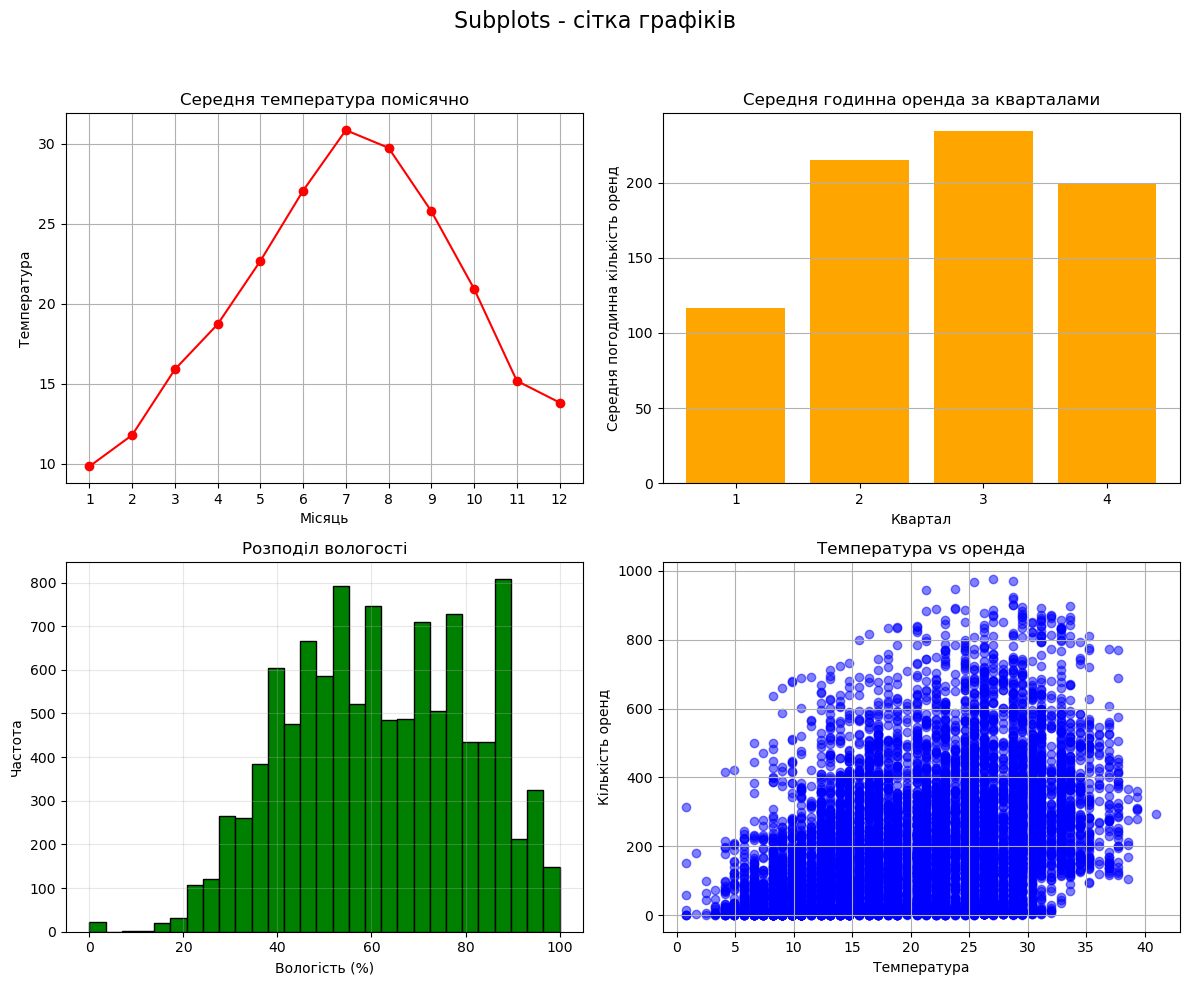

In [11]:
# 2x2 сітка графіків
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# Графік 1 - Лінійний графік 
temp_by_month = df.groupby("month")["temp"].mean()

ax[0, 0].plot(temp_by_month.index, temp_by_month.values, marker='o', color="red")
ax[0, 0].set_title("Середня температура помісячно")
ax[0, 0].set_xlabel("Місяць")
ax[0, 0].set_ylabel("Температура")
ax[0, 0].set_xticks(range(1, 13))
ax[0, 0].grid(True)


# Графік 2 - Стовпчикова діаграма
rent_by_season = df.groupby("season")["count"].mean()

ax[0, 1].bar(rent_by_season.index, rent_by_season.values, color="orange")
ax[0, 1].set_title("Середня годинна оренда за кварталами")
ax[0, 1].set_xlabel("Квартал")
ax[0, 1].set_ylabel("Середня погодинна кількість оренд")
ax[0, 1].set_xticks([1,2,3,4])
ax[0, 1].grid(axis='y')


# Графік 3 - Гістограма
bins = np.linspace(df["humidity"].min(), df["humidity"].max(), 30)

ax[1, 0].hist(df["humidity"], bins=bins, color="green",edgecolor="black")
ax[1, 0].set_title("Розподіл вологості")
ax[1, 0].set_xlabel("Вологість (%)")
ax[1, 0].set_ylabel("Частота")
ax[1, 0].grid(True, alpha=0.3)

# Графік 4 - Scatter
scatter_df = df[["temp", "count"]].copy()

ax[1, 1].scatter(scatter_df["temp"], scatter_df["count"], alpha=0.5, color="blue")
ax[1, 1].set_title("Температура vs оренда")
ax[1, 1].set_xlabel("Температура")
ax[1, 1].set_ylabel("Кількість оренд")
ax[1, 1].grid(True)


# Заголовок всієї сітки
fig.suptitle("Subplots - сітка графіків", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("Subplots_2_2.png", dpi=300, bbox_inches="tight")
plt.show()

Коли з subplot() будуємо кілька графіків дійсно складно слідкувати за розмірністю і не промахнутись. Натомість із subplots() дуже легко працювати через координати.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?